<a href="https://www.kaggle.com/code/parth2157/2018-data-science-blow-studying-cell-ipynb?scriptVersionId=353295395" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/data-science-bowl-2018/stage1_test.zip
/kaggle/input/competitions/data-science-bowl-2018/stage1_sample_submission.csv.zip
/kaggle/input/competitions/data-science-bowl-2018/stage2_sample_submission_final.csv.zip
/kaggle/input/competitions/data-science-bowl-2018/stage1_train.zip
/kaggle/input/competitions/data-science-bowl-2018/stage1_train_labels.csv.zip
/kaggle/input/competitions/data-science-bowl-2018/stage1_solution.csv.zip
/kaggle/input/competitions/data-science-bowl-2018/stage2_test_final.zip


In [2]:
# All needed libraries
import cv2
import os
import matplotlib.pyplot as plt
import zipfile

In [3]:
zip_path = "/kaggle/input/competitions/data-science-bowl-2018/stage1_train.zip"
extract_path = "/kaggle/working/data"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(extract_path)

print("Extraction complete")

Extraction complete


In [4]:
folder_name = "/d1b173875e2261f55014bd27bd7174b9ae1c769338c1b31b5d737e9e60175993/images"
total = 0
for f in os.listdir(extract_path + folder_name):
    print(f)
    total +=1
print(total)

d1b173875e2261f55014bd27bd7174b9ae1c769338c1b31b5d737e9e60175993.png
1


Path: /kaggle/working/data/d1b173875e2261f55014bd27bd7174b9ae1c769338c1b31b5d737e9e60175993/images/d1b173875e2261f55014bd27bd7174b9ae1c769338c1b31b5d737e9e60175993.png
Exists: True
Image shape: (256, 256, 3)


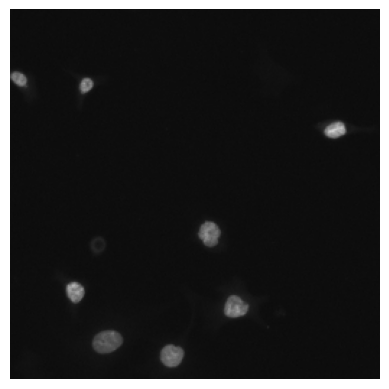

In [5]:
# Sample Image Visualization
image_name = "/d1b173875e2261f55014bd27bd7174b9ae1c769338c1b31b5d737e9e60175993.png"
image_path = extract_path + folder_name + image_name
print("Path:", image_path)
print("Exists:", os.path.exists(image_path))
img = cv2.imread(image_path)
if img is None:
    print("Error: Could not load image.")
else:
    print("Image shape:", img.shape)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.axis("off")
    plt.show()

In [6]:
# Sample mask Visualization
folder_name = "/d1b173875e2261f55014bd27bd7174b9ae1c769338c1b31b5d737e9e60175993/masks"
total = 0
for f in os.listdir(extract_path + folder_name):
    print(f)
    total +=1
print(total)

ae1fb1b8171697a32499c2b8ef1d78cabe81c07adc8c5f07c2a14a9720475023.png
a203b9d4166b9312ef53b04cc480a4a2dd9ba5cc34c9ce67320bb9d9ed79e6bd.png
e726974d21f8a5cbb0ec0d987ccc46037c87ba2eb62157df4fbd713634f13c2a.png
9354defa586f363902cef14e0801b5cf19884d4dfe85a35a076d94e1e2253062.png
05652edb21bf44d7db01745f25b3f2b7cd3204f8ec5a7feede3674613d5610ae.png
797413183f680b503b0bbdf1aa06798e879410bbe7a8d3c3191d84e475d397ec.png
da169bac4760a00e995c9def869b502619c63f651611ab91b1c07fb277b8b963.png
f9a983651a42c241d9abccef38315c95ac882bb3396b3c293969270d4f8b215e.png
4cea1bcd4ff3111c5a5eafa00b3d11ff504368399b5473607a1b1ff8637382a2.png
9


Path: /kaggle/working/data/d1b173875e2261f55014bd27bd7174b9ae1c769338c1b31b5d737e9e60175993/masks/a203b9d4166b9312ef53b04cc480a4a2dd9ba5cc34c9ce67320bb9d9ed79e6bd.png
Exists: True
Image shape: (256, 256, 3)


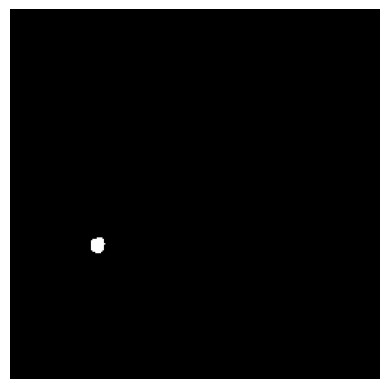

In [7]:
# Sample Mask Visualization
mask_name = "/a203b9d4166b9312ef53b04cc480a4a2dd9ba5cc34c9ce67320bb9d9ed79e6bd.png"
image_path = extract_path + folder_name + mask_name
print("Path:", image_path)
print("Exists:", os.path.exists(image_path))
img = cv2.imread(image_path)
if img is None:
    print("Error: Could not load image.")
else:
    print("Image shape:", img.shape)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.axis("off")
    plt.show()

### Work till simple experience with the data.

# Now work on the project.

### Load one image and its masks

This is your first actual image-analysis task. You need to check whether the original image and its masks line up.

Image shape: (256, 256, 3)
Number of masks: 10


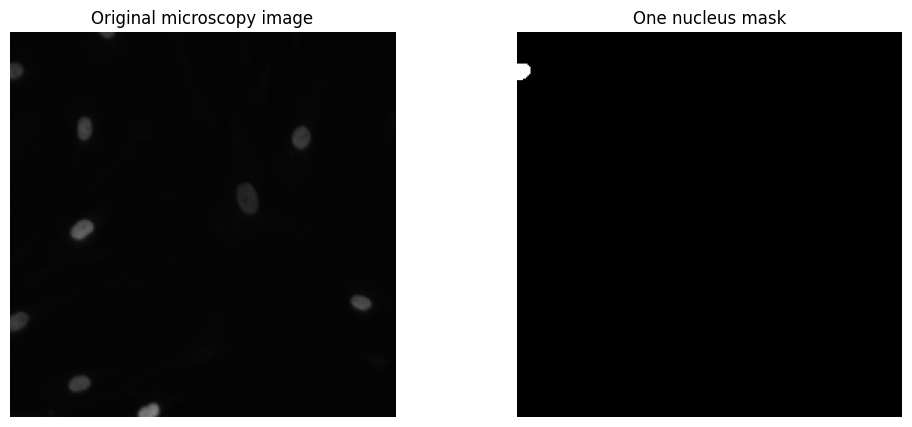

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob

sample_dirs = [
    d for d in glob.glob(extract_path + "/*")
    if os.path.isdir(d)
]

sample = sample_dirs[0]

image_path = glob.glob(sample + "/images/*")[0]
mask_paths = glob.glob(sample + "/masks/*")

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

print("Image shape:", image.shape)
print("Number of masks:", len(mask_paths))

mask = cv2.imread(mask_paths[0], cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original microscopy image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap="gray")
plt.title("One nucleus mask")
plt.axis("off")

plt.show()

What you should observe

- The original image contains cells and their surrounding structures.

- A mask represents one annotated nucleus, with foreground pixels marking that nucleus.

- Different masks in the same sample represent different nuclei.

- The image and mask should have matching height and width.

### Visualize all nuclei together

For your first U-Net, you'll use a binary mask: all nuclei are white, and everything else is black. Combine the separate instance masks to create it.

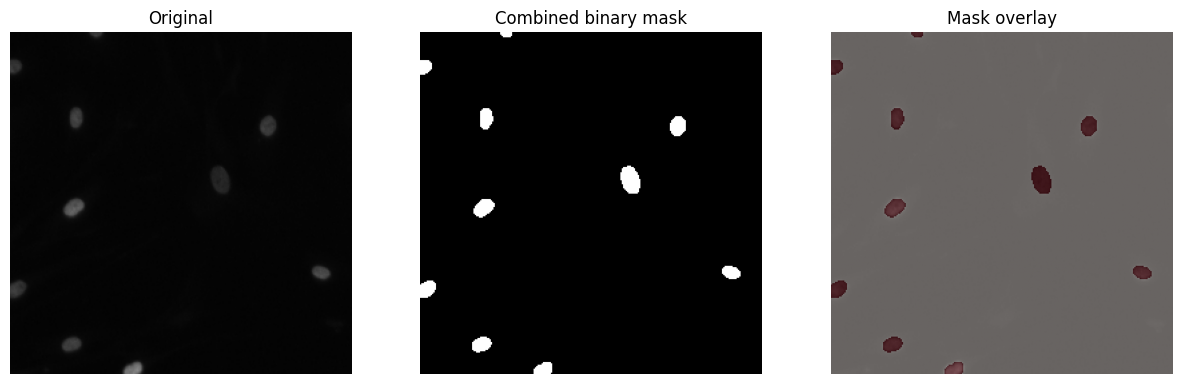

In [9]:
combined = np.zeros(
    image.shape[:2],
    dtype=np.uint8
)

for path in mask_paths:
    m = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    combined[m > 0] = 1

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(combined, cmap="gray")
plt.title("Combined binary mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(image)
plt.imshow(combined, cmap="Reds", alpha=0.4)
plt.title("Mask overlay")
plt.axis("off")

plt.show()

The overlay is particularly important. It helps you detect misalignment, missing annotations and incorrect mask loading before you spend time training.

### Perform dataset-level EDA

Now inspect more than one image. You want to know whether all images have the same dimensions and how many masks each sample contains.

In [25]:
records = []
no_image = 0
img_contain = 0
for sample in sample_dirs:
    image_files = glob.glob(sample + "/images/*")
    masks = glob.glob(sample + "/masks/*")
    
    if not image_files:
        no_image += 1
        continue
    img_contain += 1
    img = cv2.imread(image_files[0])
    h, w = img.shape[:2]

    records.append({
        "sample": os.path.basename(sample),
        "height": h,
        "width": w,
        "channels": img.shape[2],
        "num_masks": len(masks)
    })

df = pd.DataFrame(records)

print(df.head())
print(df.shape)
print("\nDataset summary:")
print(df[["height", "width", "channels", "num_masks"]].describe())

print("\nUnique image dimensions:")
print(df.groupby(["height", "width"]).size())
print("Total number folder who don't contain any images are", no_image)
print("Total number of folder which contain images are", img_contain)

                                              sample  height  width  channels  \
0  fc345dac2205deb169bd70197f07f053bada80b61ffa69...     256    256         3   
1  da31f2aa8601afec5c45180a2c448cb9c4a8ec7b35e751...     520    696         3   
2  3ebd2ab34ba86e515feb79ffdeb7fc303a074a98ba3994...     520    696         3   
3  cab4875269f44a701c5e58190a1d2f6fcb577ea79d8425...     256    256         3   
4  0d3640c1f1b80f24e94cc9a5f3e1d9e8db7bf6af7d4aba...     256    320         3   

   num_masks  
0         10  
1         62  
2        138  
3         14  
4         21  
(670, 5)

Dataset summary:
            height        width  channels   num_masks
count   670.000000   670.000000     670.0  670.000000
mean    333.991045   378.500000       3.0   43.971642
std     149.474845   204.838693       0.0   47.962530
min     256.000000   256.000000       3.0    1.000000
25%     256.000000   256.000000       3.0   15.250000
50%     256.000000   320.000000       3.0   27.000000
75%     360.000000

Then plot the number of nuclei masks per image:

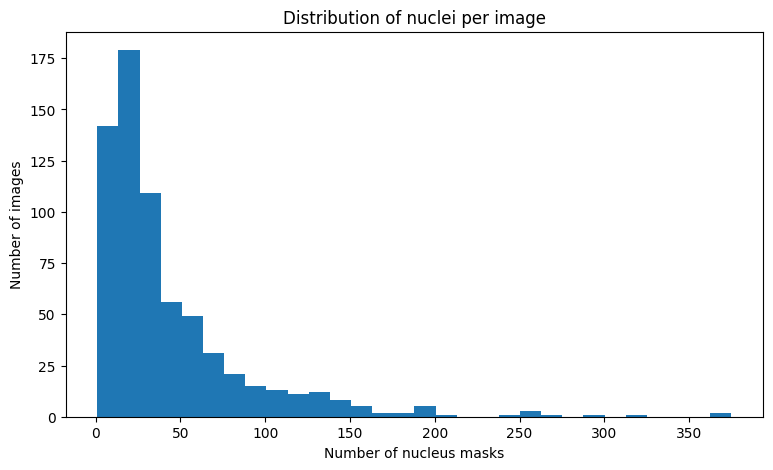

In [27]:
plt.figure(figsize=(9, 5))
plt.hist(df["num_masks"], bins=30)
plt.xlabel("Number of nucleus masks")
plt.ylabel("Number of images")
plt.title("Distribution of nuclei per image")
plt.show()

It tells you how much variation exists in the number of annotated nuclei between samples.

### Check image quality and mask validity

In [20]:
# All_Dirs = [
#     d for d in glob.glob(extract_path + "/*")
# ]
# print(len(All_Dirs))
# print(len(sample_dirs))

670
670


In [28]:
print("Original samples:", len(sample_dirs))

mask_counts = [
    len(glob.glob(d + "/masks/*"))
    for d in sample_dirs
]

print("Total individual masks:", sum(mask_counts))
print("Minimum masks per image:", min(mask_counts))
print("Maximum masks per image:", max(mask_counts))

Original samples: 670
Total individual masks: 29461
Minimum masks per image: 1
Maximum masks per image: 375
